In [1]:
from analysis import AnalyzerObject
from algorithms import MarkovGranulizer
import writing
import analysis
import pandas as pd
import numpy as np
import audioflux as af

In [23]:
path =  "..\..\corpus\\flute_sample_1"
sr = 48000
analyzer = AnalyzerObject(path, sr)
analyzer.load_y()
grain_duration = 0.140
grain_size = int(sr*grain_duration)

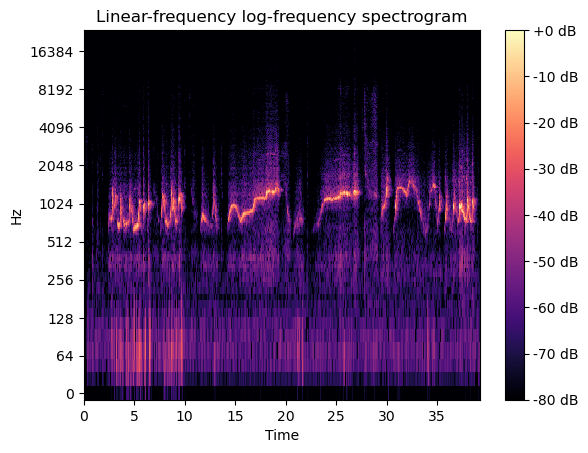

In [50]:
y,sr =af.read(path + "\\input.wav", samplate=sr)
analysis.show_spectrogram(y,sr, "log")

In [3]:
df = analyzer.compute_grain_descriptors(grain_size)
df

Length y: 1886208 Length descr y: 1886208
Length y: 1886208 Length descr y: 1886208
Length y: 1886208 Length descr y: 1886208
Length y: 1886208 Length descr y: 1886208
Length y: 1886208 Length descr y: 1886208
Length y: 1886208 Length descr y: 1886208
Length y: 1886208 Length descr y: 1886208
Length y: 1886208 Length descr y: 1886208
Length y: 1886208 Length descr y: 1886208


,id,sr,index,size,centroid,flux,rolloff,flatness,spread,skewness,kurtosis,crest,rms
0,ea7a52415,48000,0,6720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,3c964ba4c,48000,6720,6720,6536.525391,0.077357,15620.536133,0.447844,4558.615234,0.628030,2.735126,10.116220,0.000366
2,f23f2f467,48000,13440,6720,4598.620605,0.344549,18018.080078,0.294543,5348.016602,1.509978,4.474691,51.151787,0.001750
3,efd199d14,48000,20160,6720,5063.242676,0.183560,18836.382812,0.341151,6245.520020,1.233086,3.204474,69.561646,0.001426
4,c97e4efc6,48000,26880,6720,5501.485352,0.129216,19104.687500,0.368307,6463.645996,1.095306,2.823475,50.826233,0.001032
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,266658377,48000,1848000,6720,1405.707153,2758.088135,3100.000000,0.033111,1827.793945,6.641892,55.001236,147.290421,0.105567
276,4b943a232,48000,1854720,6720,1675.864380,70.559143,5810.937500,0.064015,2819.399414,4.976780,30.176117,112.324524,0.020511
277,97b00fa25,48000,1861440,6720,2719.259521,4.923347,15227.009766,0.152095,4412.806152,2.715616,9.771335,88.209503,0.005881
278,43a5941c8,48000,1868160,6720,4722.135254,2.669098,17396.650391,0.258321,5231.821289,1.508683,4.569085,42.758877,0.003812


In [4]:
analyzer.save_metadata(df, grain_duration=grain_duration)

Saved to csv to: ..\..\corpus\flute_sample_1\metadata\grain_0.14_s_metadata_e118eb9b.csv


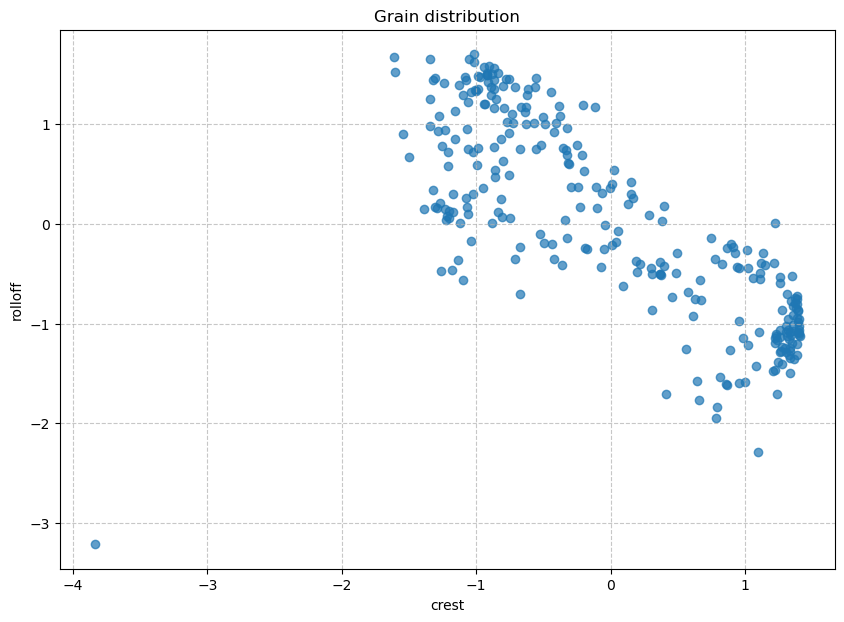

In [24]:
metadata_path = "..\..\corpus\\flute_sample_1\metadata\grain_0.14_s_metadata_e118eb9b.csv" 
df = analyzer.load_metadata(metadata_path)
_, df_scaled = analyzer.scale_metadata(df, scaler=2)
x = "rolloff"
y = "crest"
features = [x,y]
analysis.show_scatter_plt(df_scaled[x], df_scaled[y], x, y, "Grain distribution")
# df

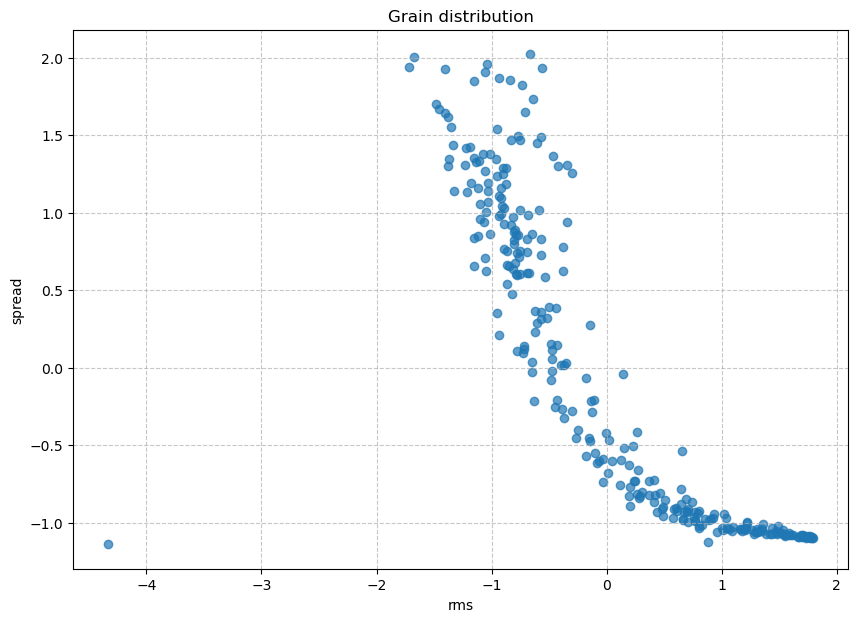

In [8]:
x = "spread"
y = "rms"
features = [x,y]
analysis.show_scatter_plt(df_scaled[x], df_scaled[y], x, y, "Grain distribution")

In [25]:
n_clusters = 2
kmeans_obj = analyzer.compute_kmeans(df_scaled, n_clusters=n_clusters, features=features)
dict_cluster, _ = analyzer.get_cluster_dict(kmeans_obj.labels_)

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [ ]:

densities = [1, 4, 9, 16, 2000]
panning = [(0.7,1),(0.3,0.2),(0.3,0.8)]
synthesizer = MarkovGranulizer(sr=analyzer.sr, densities=densities, panning=panning)
delta_t = grain_duration*20
n_iterations = 20
seed=90
n_streams = 10
np.random.seed(seed)
init_states = [np.random.randint(0, len(densities)*n_clusters) for _ in range(n_streams)]
output_buffer, params = synthesizer.run_v2(
    analyzer.y,
    n_iterations,
    delta_t=delta_t,
    n_streams=n_streams,
    window=np.hanning,
    n_clusters=n_clusters,
    seed=seed,
    init_states=init_states,
    grains=analyzer.grains(grain_size),
    dict_clusters=dict_cluster,
)
params["features"] = features 
writing.save_output_data(output_data=output_buffer.T, sr=analyzer.sr, parametre_dict=params, output_dir=path)

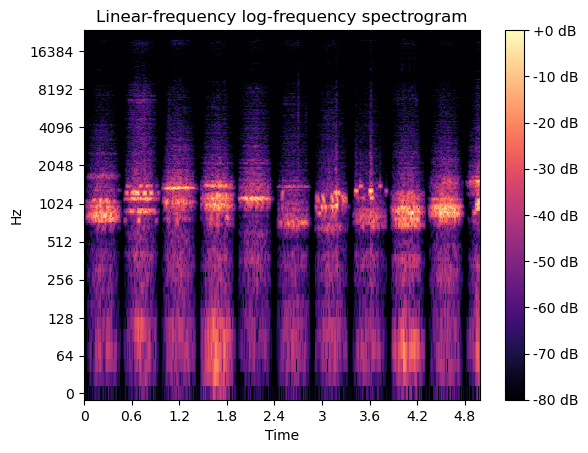

In [ ]:
path_1 = "..\\..\\corpus\\flute_sample_1\output\\20260601_a3510a.wav"
y,sr =af.read(path_1, samplate=sr)
y = y[:sr*5]
analysis.show_spectrogram(y,sr, "log")

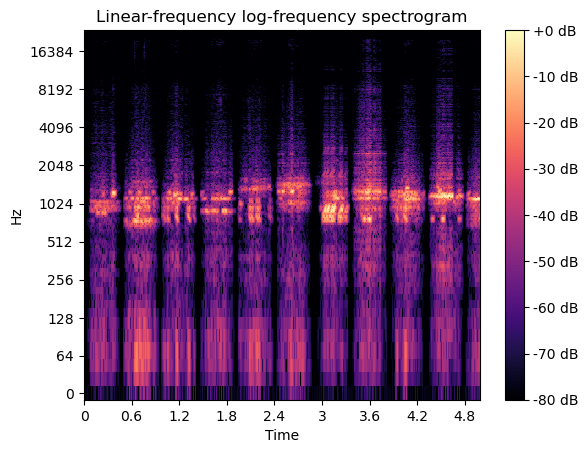

In [38]:
import audioflux as sf
path_1 = "..\\..\\corpus\\flute_sample_1\output\\20260601_83c6e6.wav"
y,sr =af.read(path_1, samplate=sr)
y = y[:sr*5]
analysis.show_spectrogram(y,sr, "log")

### Experiment 2


In [6]:
path =  "..\..\corpus\\metro_sample_1"
sr = 48000
analyzer = AnalyzerObject(path, sr)
analyzer.load_y()
grain_duration = 0.06
grain_size = int(sr*grain_duration)

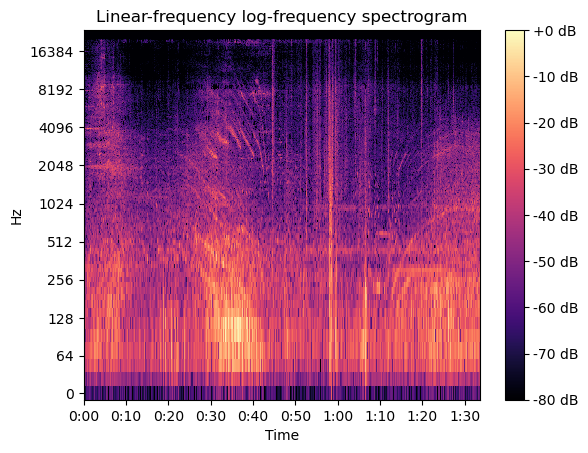

In [54]:
y,sr =af.read(path + "\\input.wav", samplate=sr)
analysis.show_spectrogram(y,sr, "log")

In [20]:
df = analyzer.compute_grain_descriptors(grain_size)

Length y: 4499456 Length descr y: 4499456
Length y: 4499456 Length descr y: 4499456
Length y: 4499456 Length descr y: 4499456
Length y: 4499456 Length descr y: 4499456
Length y: 4499456 Length descr y: 4499456
Length y: 4499456 Length descr y: 4499456
Length y: 4499456 Length descr y: 4499456
Length y: 4499456 Length descr y: 4499456
Length y: 4499456 Length descr y: 4499456


In [21]:
analyzer.save_metadata(df, grain_duration=grain_duration)

Saved to csv to: ..\..\corpus\metro_sample_1\metadata\grain_0.06_s_metadata_6a4c7efe.csv


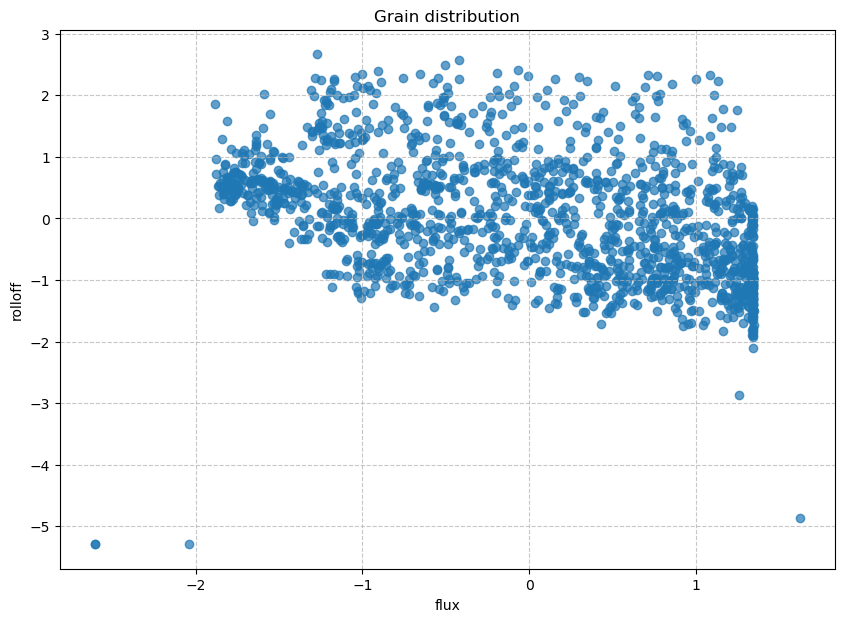

In [7]:
metadata_path = "..\..\corpus\\metro_sample_1\metadata\grain_0.06_s_metadata_6a4c7efe.csv"
df = analyzer.load_metadata(metadata_path)
_, df_scaled = analyzer.scale_metadata(df, scaler=2)
x = "rolloff"
y = "flux"
features = [x,y]
analysis.show_scatter_plt(df_scaled[x], df_scaled[y], x, y, "Grain distribution")

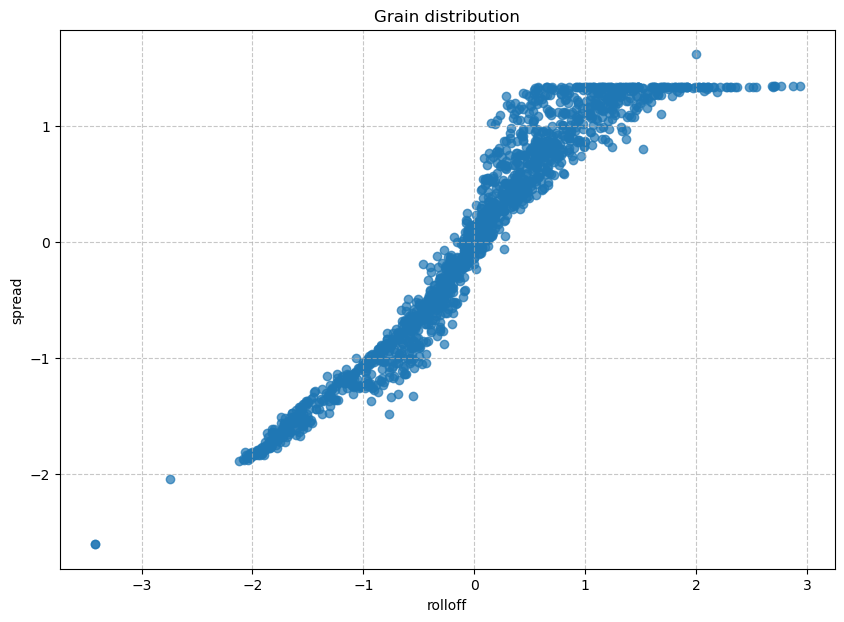

In [30]:
x = "spread"
y = "rolloff"
features = [x,y]
analysis.show_scatter_plt(df_scaled[x], df_scaled[y], x, y, "Grain distribution")

In [8]:
n_clusters = 2
kmeans_obj = analyzer.compute_kmeans(df_scaled, n_clusters=n_clusters, features=features)
dict_cluster, _ = analyzer.get_cluster_dict(kmeans_obj.labels_)

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [11]:
import numpy as np
def rev_exp(size, decay_r=1):
    t = np.linspace(0,1,size)
    window = np.exp(-t/decay_r)
    normalized_window = (window - window[-1])/(window[0]-window[-1])
    return normalized_window
rev_exp(10,1)

array([1.        , 0.83363825, 0.68477121, 0.55155914, 0.43235573,
       0.32568784, 0.23023722, 0.14482425, 0.06839336, 0.        ])

In [16]:
def normalize_output(data):
    data_float = data.astype(np.float32)
    peak = np.max(np.abs(data_float))
    if peak == 0:
        normalized = data_float
    else:
        normalized = data_float / peak
    return normalized

In [32]:

densities = [1, 4, 9, 16, 200]
panning = [(0.8,1),(0.3,0.2),(0.3,0.8)]
synthesizer = MarkovGranulizer(sr=analyzer.sr, densities=densities, panning=panning)
delta_t = grain_duration*10
n_iterations = 4*4
seed=90
n_streams = 10
np.random.seed(seed)
init_states = [np.random.randint(0, len(densities)*n_clusters) for _ in range(n_streams)]
output_buffer, params = synthesizer.run_v2(
    analyzer.y,
    n_iterations,
    delta_t=delta_t,
    n_streams=n_streams,
    window=rev_exp,
    n_clusters=n_clusters,
    seed=seed,
    init_states=init_states,
    grains=analyzer.grains(grain_size),
    dict_clusters=dict_cluster,
)
params["features"] = features 
writing.save_output_data(output_data=normalize_output(output_buffer.T), sr=analyzer.sr, parametre_dict=params, output_dir=path)

In [28]:

densities = [1, 4, 9, 16, 2000, 10000, 20000]
panning = [(0.8,1),(0.3,0.2),(0.3,0.8)]
synthesizer = MarkovGranulizer(sr=analyzer.sr, densities=densities, panning=panning)
delta_t = grain_duration*20
n_iterations = 4
seed=90
n_streams = 10
np.random.seed(seed)
init_states = [np.random.randint(0, len(densities)*n_clusters) for _ in range(n_streams)]
output_buffer, params = synthesizer.run_v2(
    analyzer.y,
    n_iterations,
    delta_t=delta_t,
    n_streams=n_streams,
    window=rev_exp,
    n_clusters=n_clusters,
    seed=seed,
    init_states=init_states,
    grains=analyzer.grains(grain_size),
    dict_clusters=dict_cluster,
)
params["features"] = features 
writing.save_output_data(output_data=normalize_output(output_buffer.T), sr=analyzer.sr, parametre_dict=params, output_dir=path)

In [14]:

densities = [1, 4, 9, 16, 2000]
panning = [(0.7,1),(0.3,0.2),(0.3,0.8)]
synthesizer = MarkovGranulizer(sr=analyzer.sr, densities=densities, panning=panning)
delta_t = grain_duration*20
n_iterations = 20
seed=90
n_streams = 10
np.random.seed(seed)
init_states = [np.random.randint(0, len(densities)*n_clusters) for _ in range(n_streams)]
output_buffer, params = synthesizer.run_v2(
    analyzer.y,
    n_iterations,
    delta_t=delta_t,
    n_streams=n_streams,
    window=rev_exp,
    n_clusters=n_clusters,
    seed=seed,
    init_states=init_states,
    grains=analyzer.grains(grain_size),
    dict_clusters=dict_cluster,
)
params["features"] = features 
writing.save_output_data(output_data=normalize_output(output_buffer.T), sr=analyzer.sr, parametre_dict=params, output_dir=path)

In [ ]:

densities = [1, 3, 9, 27]
panning = [(0.7,1),(0.3,0.2),(0.3,0.8)]
synthesizer = MarkovGranulizer(sr=analyzer.sr, densities=densities, panning=panning)
delta_t = grain_duration*8
n_iterations = 50//2
seed=90
n_streams = 10
np.random.seed(seed)
init_states = [np.random.randint(0, len(densities)*n_clusters) for _ in range(n_streams)]
output_buffer, params = synthesizer.run_v2(
    analyzer.y,
    n_iterations,
    delta_t=delta_t,
    n_streams=n_streams,
    window=np.hanning,
    n_clusters=n_clusters,
    seed=seed,
    init_states=init_states,
    grains=analyzer.grains(grain_size),
    dict_clusters=dict_cluster,
)
params["features"] = features 

writing.save_output_data(output_data=normalize_output(output_buffer.T), sr=analyzer.sr, parametre_dict=params, output_dir=path)

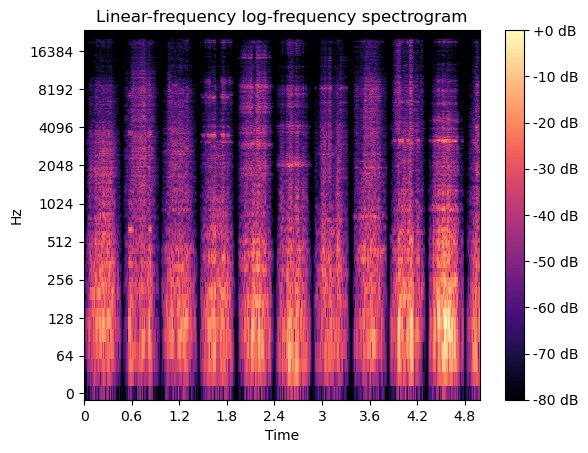

In [35]:
import audioflux as af
path_1 = "..\\..\\corpus\metro_sample_1\output\\20260601_e65f58.wav"
y,sr =af.read(path_1, samplate=sr)
y = y[:sr*5]
analysis.show_spectrogram(y,sr, "log")

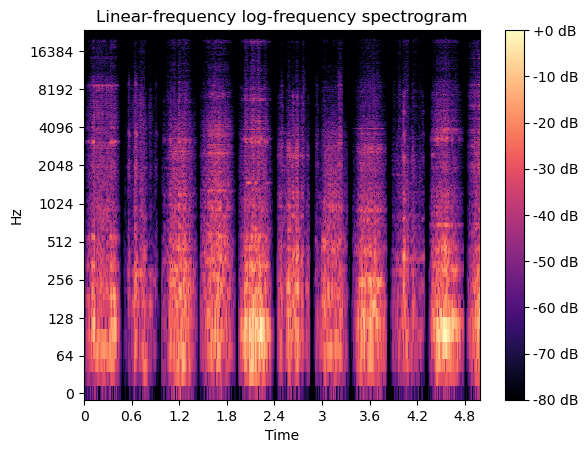

In [36]:
import audioflux as sf
path_1 = "..\\..\\corpus\metro_sample_1\output\\20260601_a71050.wav"
y,sr =af.read(path_1, samplate=sr)
y = y[:sr*5]
analysis.show_spectrogram(y,sr, "log")

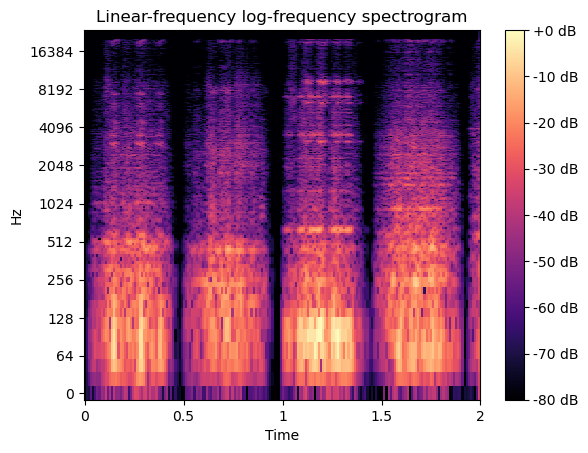

In [19]:
import audioflux as sf
path_1 = "..\\..\\corpus\metro_sample_1\output\\20260601_66efb7.wav"
y,sr =af.read(path_1, samplate=sr)
y = y[:sr*2]
analysis.show_spectrogram(y,sr,"log")

Honourable mentions

In [18]:
import audioflux as af

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


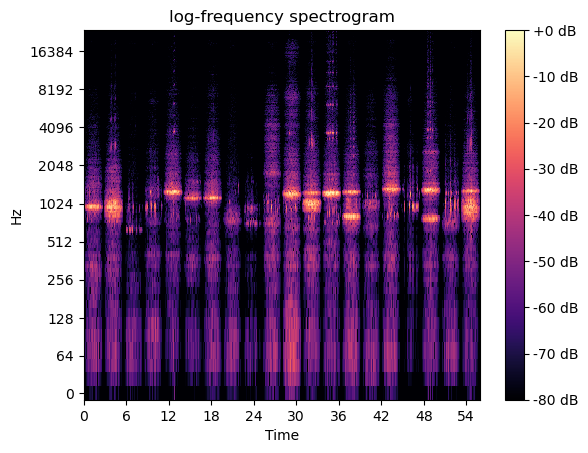

In [26]:
path_1 = "..\\..\\corpus\\flute_sample_1\output\\20260601_963589.wav"
y,sr =af.read(path_1, samplate=sr)
analysis.show_spectrogram(y,sr,"log")

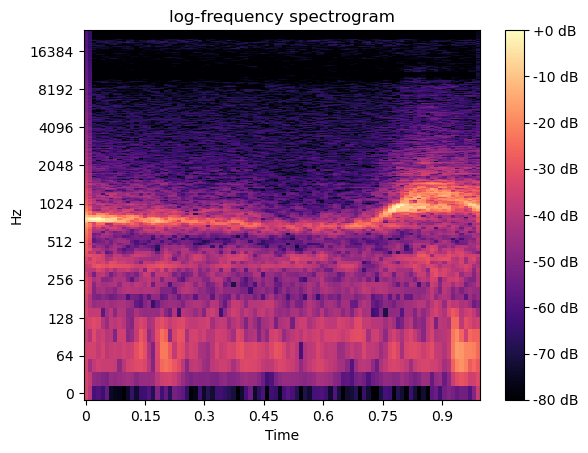

In [6]:
sr=48000
path_1 = "..\\..\\corpus\\flute_sample_1\input.wav"
y,sr =af.read(path_1, samplate=sr)
analysis.show_spectrogram(y[sr*12:sr*13],sr,"log")

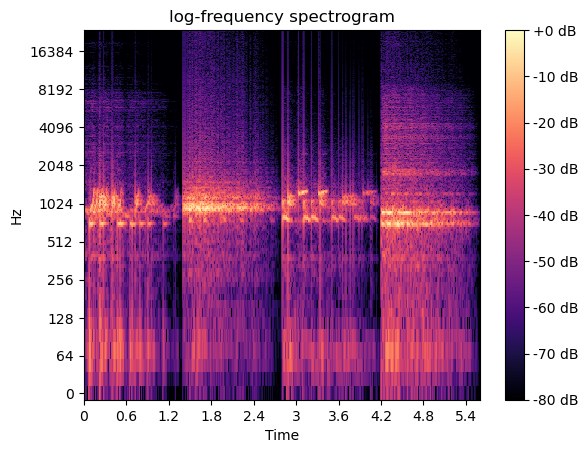

In [8]:
sr=48000
path_1 = "..\\..\\corpus\\flute_sample_1\output\\20260601_514483.wav"
y,sr =af.read(path_1, samplate=sr)
analysis.show_spectrogram(y,sr,"log")

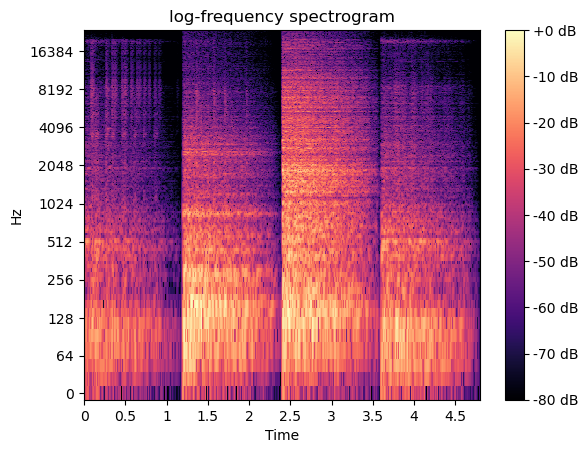

In [15]:
sr=48000
path_1 = "..\\..\\corpus\\metro_sample_1\output\\20260601_d6aaa4.wav"
y,sr =af.read(path_1, samplate=sr)
analysis.show_spectrogram(y[:int(sr*4.8)],sr,"log")

In [23]:
import sounddevice as sd

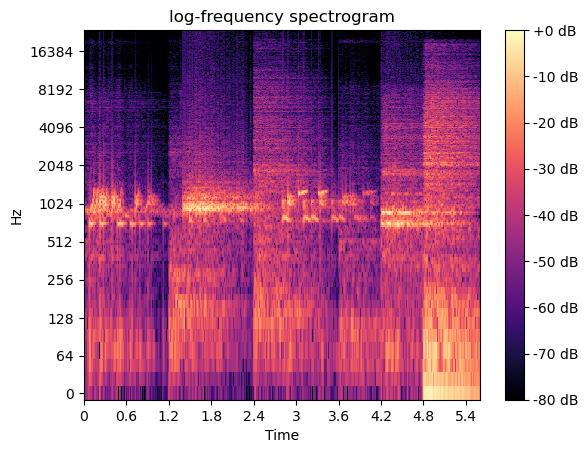

In [24]:
sr=48000
path_1 = "..\\..\\corpus\\metro_sample_1\output\\20260601_d6aaa4.wav"
y1,sr =af.read(path_1, samplate=sr)
sr=48000
path_2 = "..\\..\\corpus\\flute_sample_1\output\\20260601_514483.wav"
y2,sr =af.read(path_2, samplate=sr)
# analysis.show_spectrogram(y,sr,"log")
summed_streams = normalize_output(y1[:268800]+y2)
analysis.show_spectrogram(summed_streams,sr,"log")


In [25]:
sd.play(summed_streams)